In [1]:
import torch
import torch.nn.functional as F

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print(len(words))

32033


In [2]:
block_size = 3
X, Y = [], []

for w in words[:5]:     # initially lets try with first 5 words
    print(w)
    context = [0] * block_size    # start with [0, 0, 0] --> (3 dot)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix]    # slide the window by one step

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .


In [3]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

print(X.shape, X.dtype)
print(Y.shape, Y.dtype)

torch.Size([228146, 3]) torch.int64
torch.Size([228146]) torch.int64


In [4]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)

In [5]:
print(C[5])

tensor([-0.4713,  0.7868])


In [6]:
emb = C[X]
print(emb.shape)

torch.Size([228146, 3, 2])


In [7]:
emb_flat = emb.view(-1,6)
print(emb_flat.shape)

torch.Size([228146, 6])


In [8]:
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)

h = torch.tanh(emb_flat @ W1 + b1)
print(h.shape)

torch.Size([228146, 100])


In [9]:
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)

logits = h @ W2 + b2
print(logits.shape)

torch.Size([228146, 27])


In [10]:
loss = F.cross_entropy(logits, Y)
print(loss)

tensor(17.9455)


In [11]:
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.01

emb = C[X]
emb_flat = emb.view(-1, 6)
h = torch.tanh(emb_flat @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, Y)
print(loss)

tensor(3.3056)


In [12]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = (torch.randn((100, 27), generator=g) * 0.01).requires_grad_(True)
b2 = (torch.randn(27, generator=g) * 0.01).requires_grad_(True)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [13]:
for k in range(200):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    # backward pass
    for p in parameters: 
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

    if k % 20 == 0:
        print(f'iter {k}: loss={loss.item():.4f}')

iter 0: loss=3.3032
iter 20: loss=2.8233
iter 40: loss=2.7440
iter 60: loss=2.7100
iter 80: loss=2.6895
iter 100: loss=2.6749
iter 120: loss=2.6634
iter 140: loss=2.6540
iter 160: loss=2.6459
iter 180: loss=2.6387


In [14]:
for k in range(10000):
    # generate minibatch - select random 32 samples
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass (just over the 32 samples)
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # bacward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

    if k % 1000 == 0:
        print(f'iter {k}: loss={loss.item():.4f}')

iter 0: loss=2.5562
iter 1000: loss=2.3221
iter 2000: loss=2.3329
iter 3000: loss=2.4211
iter 4000: loss=2.3017
iter 5000: loss=2.5549
iter 6000: loss=2.5296
iter 7000: loss=2.2367
iter 8000: loss=2.1826
iter 9000: loss=2.5065


In [15]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lossi = []
lri = []

for k in range(1000):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lrs[k]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[k].item())
    lossi.append(loss.item())

Text(0, 0.5, 'loss')

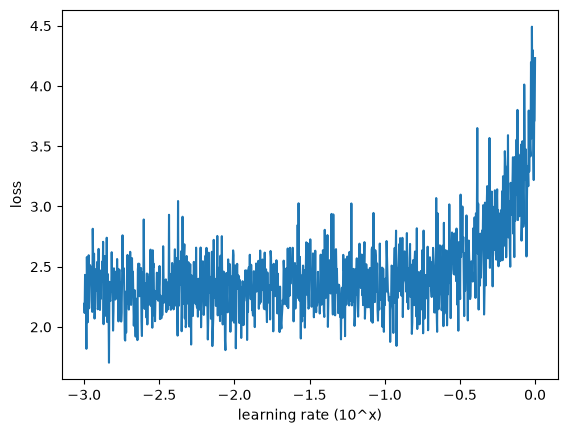

In [16]:
import matplotlib.pyplot as plt
plt.plot(lri, lossi)
plt.xlabel('learning rate (10^x)')
plt.ylabel('loss')

In [17]:
for k in range(30000):
    ix = torch.randint(0, X.shape[0], (32,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    if k % 3000 == 0:
        print(f'iter {k}: loss={loss.item():.4f}')

print('final loss:', loss.item())

iter 0: loss=3.7207
iter 3000: loss=2.0766
iter 6000: loss=2.1265
iter 9000: loss=2.0689
iter 12000: loss=2.1266
iter 15000: loss=2.1524
iter 18000: loss=2.2310
iter 21000: loss=2.5439
iter 24000: loss=2.1991
iter 27000: loss=2.0435
final loss: 2.2153477668762207


In [18]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.296678304672241


In [19]:
import random

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
words_shuffled = words.copy()
random.shuffle(words_shuffled)

n1 = int(0.8 * len(words_shuffled))
n2 = int(0.9 * len(words_shuffled))

Xtr, Ytr   = build_dataset(words_shuffled[:n1])      # %80 - train
Xdev, Ydev = build_dataset(words_shuffled[n1:n2])    # %10 - validation
Xte, Yte   = build_dataset(words_shuffled[n2:])      # %10 - test

print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [21]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = (torch.randn((100, 27), generator=g) * 0.01).requires_grad_(True)
b2 = (torch.randn(27, generator=g) * 0.01).requires_grad_(True)
parameters = [C, W1, b1, W2, b2]

for k in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))   # attention : sampling from Xtr

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

# real loss in the all of train-set when the training ends
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss_train = F.cross_entropy(logits, Ytr)
print('train loss:', loss_train.item())

# loss in the dev (validation) set , the model has never seen this
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits, Ydev)
print('dev loss:', loss_dev.item())

train loss: 2.313568115234375
dev loss: 2.320072650909424


In [22]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size   # start with [0, 0, 0]
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

dex.
daidaller.
ile.
kayde.
dinichana.
nylla.
kyn.
tar.
samiyah.
jansi.
iota.
mic.
jen.
kaugk.
treda.
kamerle.
sadey.
niaviyny.
fols.
milli.
